In [120]:
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns 
from sklearn.model_selection import train_test_split

In [121]:
# read data
data = pd.read_csv("dataset\loan_approval_data.csv")
data.head()

,Applicant_ID,Applicant_Income,Coapplicant_Income,Employment_Status,Age,Marital_Status,Dependents,Credit_Score,Existing_Loans,DTI_Ratio,Savings,Collateral_Value,Loan_Amount,Loan_Term,Loan_Purpose,Property_Area,Education_Level,Gender,Employer_Category,Loan_Approved
0,1.0,17795.0,1387.0,Salaried,51.0,Married,0.0,637.0,4.0,0.53,19403.0,45638.0,16619.0,84.0,Personal,Urban,Not Graduate,Female,Private,No
1,2.0,2860.0,2679.0,Salaried,46.0,Married,3.0,621.0,2.0,0.30,2580.0,49272.0,38687.0,NaN,Car,Semiurban,Graduate,NaN,Private,No
2,3.0,7390.0,2106.0,Salaried,25.0,Single,2.0,674.0,4.0,0.20,13844.0,6908.0,27943.0,72.0,NaN,Urban,NaN,Female,Government,Yes
3,4.0,13964.0,8173.0,Salaried,40.0,Married,2.0,579.0,3.0,0.31,9553.0,10844.0,27819.0,60.0,Business,Rural,Graduate,Female,Government,No
4,5.0,13284.0,4223.0,Self-employed,31.0,Single,2.0,721.0,1.0,0.29,9386.0,37629.0,12741.0,72.0,Car,NaN,Graduate,Male,Private,Yes


In [122]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 20 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Applicant_ID        950 non-null    float64
 1   Applicant_Income    950 non-null    float64
 2   Coapplicant_Income  950 non-null    float64
 3   Employment_Status   950 non-null    object 
 4   Age                 950 non-null    float64
 5   Marital_Status      950 non-null    object 
 6   Dependents          950 non-null    float64
 7   Credit_Score        950 non-null    float64
 8   Existing_Loans      950 non-null    float64
 9   DTI_Ratio           950 non-null    float64
 10  Savings             950 non-null    float64
 11  Collateral_Value    950 non-null    float64
 12  Loan_Amount         950 non-null    float64
 13  Loan_Term           950 non-null    float64
 14  Loan_Purpose        950 non-null    object 
 15  Property_Area       950 non-null    object 
 16  Educati

In [123]:
data.isnull().sum()

Applicant_ID          50
Applicant_Income      50
Coapplicant_Income    50
Employment_Status     50
Age                   50
Marital_Status        50
Dependents            50
Credit_Score          50
Existing_Loans        50
DTI_Ratio             50
Savings               50
Collateral_Value      50
Loan_Amount           50
Loan_Term             50
Loan_Purpose          50
Property_Area         50
Education_Level       50
Gender                50
Employer_Category     50
Loan_Approved         50
dtype: int64

In [124]:
# Catgorical and Numeric Columns
categorical_values = data.select_dtypes(include=["object"]).columns
numeric_values = data.select_dtypes(include=["number"]).columns

In [125]:
# Simple Imupter
from sklearn.impute import SimpleImputer
num_imputer = SimpleImputer(strategy="mean")
data[numeric_values]= num_imputer.fit_transform(data[numeric_values])


In [126]:
cat_imputer = SimpleImputer(strategy ="most_frequent")
data[categorical_values] = cat_imputer.fit_transform(data[categorical_values])

In [127]:
data.isnull().sum()


Applicant_ID          0
Applicant_Income      0
Coapplicant_Income    0
Employment_Status     0
Age                   0
Marital_Status        0
Dependents            0
Credit_Score          0
Existing_Loans        0
DTI_Ratio             0
Savings               0
Collateral_Value      0
Loan_Amount           0
Loan_Term             0
Loan_Purpose          0
Property_Area         0
Education_Level       0
Gender                0
Employer_Category     0
Loan_Approved         0
dtype: int64

# EDA

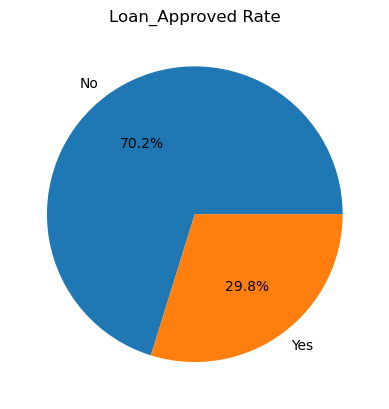

In [128]:
# To Check How Balanced Our Classes Are:
class_count = data["Loan_Approved"].value_counts()
plt.pie(class_count,labels=["No","Yes"],autopct= "%1.1f%%")
plt.title("Loan_Approved Rate")
plt.show();

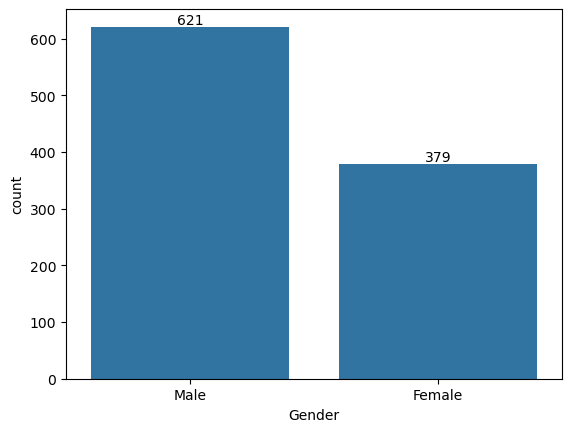

In [129]:
gender_count = data["Gender"].value_counts()
ax = sns.barplot(gender_count)
ax.bar_label(ax.containers[0])
plt.show;

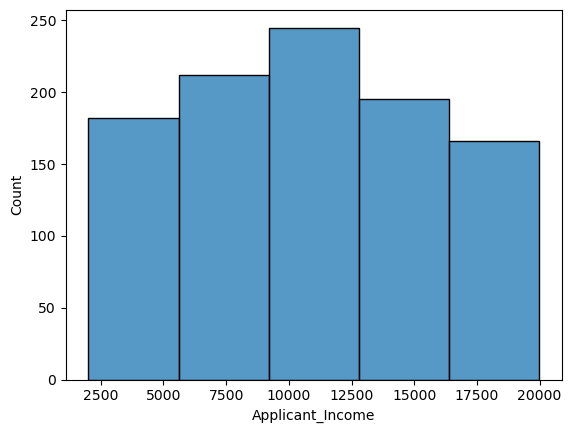

In [130]:
# analyze Income
sns.histplot(
    data = data,
    x = "Applicant_Income",
    bins=5
)
plt.show();

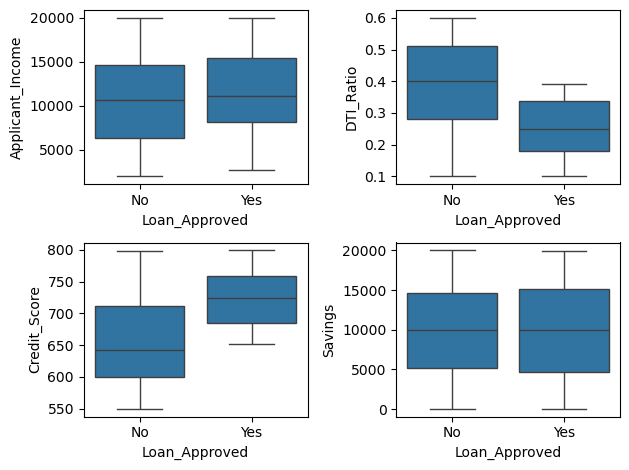

In [131]:
# outlier :
fig,axes = plt.subplots(2,2)
sns.boxplot(ax=axes[0,0],data = data, x = "Loan_Approved",y="Applicant_Income")
sns.boxplot(ax=axes[0,1],data = data, x = "Loan_Approved",y="DTI_Ratio")
sns.boxplot(ax=axes[1,0],data = data, x = "Loan_Approved",y="Credit_Score")
sns.boxplot(ax=axes[1,1],data = data, x = "Loan_Approved",y="Savings")
plt.tight_layout()
plt.show();

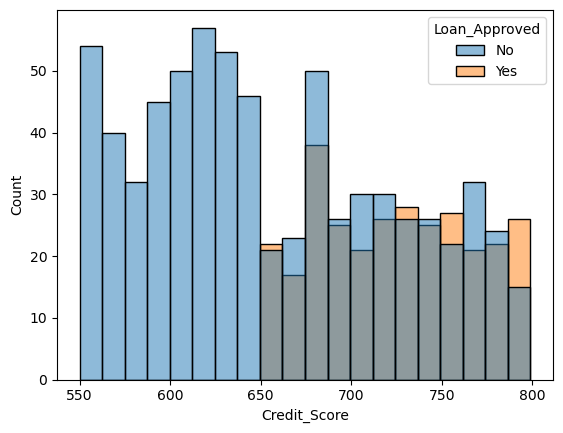

In [119]:
sns.histplot(
    data=data,
    x ="Credit_Score",
    hue="Loan_Approved",
    bins=20
);

In [96]:
# Split into features and label
X = data.drop(columns=["Loan_Approved"],axis=1)
y = data["Loan_Approved"]

In [9]:
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=42)

In [23]:
# OneHotEncoder
from sklearn.preprocessing import OneHotEncoder
ohe = OneHotEncoder()
cat_values = ["","",]

In [24]:
from sklearn.preprocessing import OrdinalEncoder
oe = OrdinalEncoder()


In [25]:
from sklearn.preprocessing import StandardScaler
Scaler = StandardScaler()
X_train = Scaler.fit_transform(X_train)
X_test = Scaler.transform(X_test)

ValueError: could not convert string to float: 'Salaried'

In [ ]:
from sklearn.ensemble import RandomForestClassifier
model = RandomForestClassifier()
model.fit(X_train,y_train)

In [ ]:
y_preds = model.predict(X_test)

In [ ]:
from sklearn.metrics import classification_report,confusion_matrix
print(classification_report(y_preds,y_test))
print(confusion_matrix(y_preds,y_test))